# T18 follow-up -- Background-Suppression Loss (arm "A2_bg")

**Status: NOT YET RUN.** New notebook, not a modification of `T18_lung_region_attention.ipynb` --
the frozen A0-A5 ablation, its committed checkpoints, and every number already written into
`docs/paper/short_paper.tex` and `artifacts/T18_lung_attention/T18_module_card.md` are untouched
by this file.

**What this tests:** even in arm A2 (the full proposed model), Grad-CAM energy is not fully
inside the lungs (EIL = 0.374, i.e. 62.6% of energy is still *outside* the lungs on average --
visible directly in `docs/paper/figures/covid_shortcut_example_crop.png`'s third panel, which
still shows a hot spot on the "PORTATIL AP" acquisition marker even after A2's fix). This is
consistent with the reported numbers, not a bug -- the residual gate `f' = f * (1 + a)` never
fully zeroes background features by design.

`src/modules/lung_attention.py` already implements an opt-in **background-suppression loss**
(`background_suppression_loss`, `lambda_bg` in `compute_total_loss`) that directly penalizes
attention *mass* placed outside the lung mask -- a different, more direct objective than the
existing guidance loss, which only pushes the attention *map* toward the mask's shape. It is
fully wired through `run_epoch` / `train_phase` / `run_full_arm` already (`lambda_bg` defaults to
`0.0`, which is why every frozen A0-A5 arm is unaffected by it existing) -- **no `src/` code
changes are needed to use it**, only a new arm configuration, which is what this notebook adds.

**New arm, not a redefinition:** this notebook trains **A2_bg** = arm A2's exact architecture and
`lambda_att`, plus a non-zero `lambda_bg`. It does not retrain or touch A0-A5.

**Design doc:** `artifacts/T18_lung_attention/T18_module_card.md` section 10 ("Optional
extensions") scoped this exact experiment in advance: *"a separate, later 'A2+bg' experiment, not
a redefinition of A2."*

**Platform:** Kaggle, T4 GPU (same as T18).


## Environment check

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute capability: sm_{major}{minor}")


PyTorch: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4
Compute capability: sm_75


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## W&B authentication

Same pattern as `T18_lung_region_attention.ipynb` -- see `docs/wandb_setup.md`. Required before
any `run_full_arm` call in a committed (Save & Run All) Kaggle session.

In [3]:
import os

# Kaggle: Add-ons -> Secrets -> add a secret named WANDB_API_KEY, attached to *this* notebook.
try:
    from kaggle_secrets import UserSecretsClient
    os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")
    print("W&B API key loaded from Kaggle Secrets -- runs will log online.")
except Exception as e:
    print(f"No WANDB_API_KEY secret available ({e}) -- falling back to offline W&B logging.")
    os.environ["WANDB_MODE"] = "offline"


No WANDB_API_KEY secret available (Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 135499052 and label WANDB_API_KEY.'], 'error': {'code': 5}, 'wasSuccessful': False}.) -- falling back to offline W&B logging.


## Repo + config

Reuses `configs/densenet121_lung_attention.yaml` unchanged (arm A2's own config) -- `lambda_bg`
is added per-arm below via `merge_overrides`, exactly the way every other T18 arm overrides the
base config, so this file is never edited.

In [4]:
import os

# Kaggle setup: clone the repo so `src` is importable. Skip if running from a local clone
# (src/ already sitting next to this notebook).
REPO_URL = "https://github.com/Ravindu-Pathirana/Chest-X-ray-Disease-Detection.git"
REPO_BRANCH = "main"  # adjust if the branch this experiment should build on hasn't merged to main yet
REPO_DIR = "/kaggle/working/Chest-X-ray-Disease-Detection"

if os.path.isdir("/kaggle/working") and not os.path.exists(os.path.join(REPO_DIR, "src")):
    if not os.path.exists(REPO_DIR):
        !git clone --branch $REPO_BRANCH --single-branch $REPO_URL $REPO_DIR
    else:
        !git -C $REPO_DIR fetch origin $REPO_BRANCH && git -C $REPO_DIR checkout $REPO_BRANCH && git -C $REPO_DIR pull
    %pip install -q -r $REPO_DIR/requirements.txt
    %pip install -q timm grad-cam


Cloning into '/kaggle/working/Chest-X-ray-Disease-Detection'...
remote: Enumerating objects: 667, done.
remote: Counting objects: 100% (343/343), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 667 (delta 142), reused 257 (delta 98), pack-reused 324 (from 1)
Receiving objects: 100% (667/667), 23.74 MiB | 31.13 MiB/s, done.
Resolving deltas: 100% (279/279), done.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path("/kaggle/working/Chest-X-ray-Disease-Detection")
sys.path.insert(0, str(REPO_ROOT))

from src.utils import load_config, merge_overrides

cfg = load_config(REPO_ROOT / "configs" / "densenet121_lung_attention.yaml")
print("Loaded base config for experiment:", cfg["experiment"]["name"])


Loaded base config for experiment: T18_lung_attention


## Data

Identical to T18's own S2 -- same `build_dataloaders` call, same committed split manifest
(`artifacts/splits/split_manifest_v1.csv`), same seed. This pipeline was already verified once
(T18's S2 alignment-eyeball check); only a lightweight shape/size assert is repeated here rather
than the full plotting cell, since nothing about the data layer changes for this experiment.

In [6]:
from pathlib import Path
from src.datasets import build_dataloaders

_LOCAL_DATA_DIR = "/Volumes/My Disk 2/My Projects/Chest Disease Detection/COVID-19_Radiography_Dataset"
_KAGGLE_DATA_DIR = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
DATA_DIR = _LOCAL_DATA_DIR if Path(_LOCAL_DATA_DIR).exists() else _KAGGLE_DATA_DIR
print("Using DATA_DIR:", DATA_DIR)

SPLIT_MANIFEST = REPO_ROOT / "artifacts" / "splits" / "split_manifest_v1.csv"
assert SPLIT_MANIFEST.exists(), f"{SPLIT_MANIFEST} not found -- this must be the committed manifest, never regenerated."

train_loader, val_loader, test_loader, class_names, train_targets, datasets = build_dataloaders(
    DATA_DIR,
    img_size=cfg["dataset"]["image_size"],
    batch_size=cfg["training"]["batch_size"],
    seed=cfg["experiment"]["seed"],
    num_workers=4,
    split_manifest_path=SPLIT_MANIFEST,
)
assert (len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)) == (14815, 3175, 3175)
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Train/Val/Test sizes: {len(train_loader.dataset)}/{len(val_loader.dataset)}/{len(test_loader.dataset)}")

import torch.nn as nn
from src.datasets import compute_class_weights

class_weights = compute_class_weights(train_targets, num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", class_weights.cpu().tolist())


Using DATA_DIR: /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
Classes (4): ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train/Val/Test sizes: 14815/3175/3175
Class weights: [1.4633543491363525, 0.8801687359809875, 0.5191687941551208, 3.9317941665649414]


## Module imports

Everything below is imported unchanged from `src/modules` -- no new module code, only a new
notebook orchestrating existing, already-tested functions (`background_suppression_loss` and
`lambda_bg` are already inside `compute_total_loss`/`run_full_arm`, not added here).

In [7]:
from src.modules import (
    build_model, freeze_backbone, unfreeze_final_blocks,
    build_optimizer, build_scheduler, best_history_row,
    train_phase, evaluate, run_full_arm,
    get_taps, cam_for,
    background_attention, energy_inside_lung,
    stratified_cam_subset, build_per_image_predictions, build_comparison_table, check_acceptance_criteria,
)
from src.utils import set_seed, initialize_wandb, generate_run_name, finish_run
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Step 1 -- lambda* (attention guidance) from T18's own committed sweep

Reuses T18's already-selected `lambda_att` (the sweep that produced A2 itself) -- this experiment
only adds `lambda_bg` on top of the existing, unchanged A2 recipe. Falls back to the documented
final value (1.0, per `short_paper.tex` / the module card) if the committed sweep artifact isn't
present in this session for some reason.

In [8]:
SWEEP_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "sweep"
SELECTED_CONFIG_PATH = SWEEP_ROOT / "selected_config.json"

if SELECTED_CONFIG_PATH.exists():
    with open(SELECTED_CONFIG_PATH) as f:
        selected = json.load(f)
    LAMBDA_STAR = selected["lambda_att"]
    print(f"Using lambda* = {LAMBDA_STAR} (loaded from {SELECTED_CONFIG_PATH})")
else:
    LAMBDA_STAR = 1.0
    print(f"{SELECTED_CONFIG_PATH} not found in this session -- falling back to the documented "
          f"final value LAMBDA_STAR = {LAMBDA_STAR} (short_paper.tex / T18_module_card.md section 3).")


Using lambda* = 1.0 (loaded from /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/sweep/selected_config.json)


## Step 2 -- lambda_bg short-schedule sweep

Mirrors T18's own S9 lambda_att sweep exactly (same short schedule, same pre-registered selection
rule), applied to the new axis. `lambda_att` and `gate_mode` are held fixed at A2's own values for
every candidate here -- only `lambda_bg` varies.

**This value has never been tuned before** -- unlike `lambda_att`, there is no prior sweep to
fall back to, so this step is not optional the way Step 1's fallback is.

In [9]:
BG_SWEEP_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "bg_suppression_followup" / "sweep"
BG_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
SEED = cfg["experiment"]["seed"]

TUNE_PHASE1_EPOCHS = 4
TUNE_PHASE2_EPOCHS = 6
TUNE_PATIENCE = 3

BASE = {
    "phase1_lr": cfg["training"]["phase1_lr"],
    "phase2_lr": cfg["training"]["phase2_lr"],
    "weight_decay": cfg["training"]["weight_decay"],
    "optimizer": cfg["training"]["optimizer"],
    "scheduler": cfg["scheduler"]["name"],
}

# Same order of magnitude as lambda_att's own swept range (T18 S9: {0, 0.1, 0.3, 0.5, 1.0}) --
# an untested first-guess grid, not derived from any prior result for lambda_bg specifically.
BG_TUNING_CONFIGS = [
    {"name": "bg_0.0", "lambda_bg": 0.0, **BASE},  # == plain A2, the reference row
    {"name": "bg_0.1", "lambda_bg": 0.1, **BASE},
    {"name": "bg_0.3", "lambda_bg": 0.3, **BASE},
    {"name": "bg_0.5", "lambda_bg": 0.5, **BASE},
    {"name": "bg_1.0", "lambda_bg": 1.0, **BASE},
]
pd.DataFrame(BG_TUNING_CONFIGS)


,name,lambda_bg,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler
0,bg_0.0,0.0,0.00412,0.000062,0.000019,adam,plateau
1,bg_0.1,0.1,0.00412,0.000062,0.000019,adam,plateau
2,bg_0.3,0.3,0.00412,0.000062,0.000019,adam,plateau
3,bg_0.5,0.5,0.00412,0.000062,0.000019,adam,plateau
4,bg_1.0,1.0,0.00412,0.000062,0.000019,adam,plateau


In [10]:
bg_tuning_results = []

for sweep_cfg in BG_TUNING_CONFIGS:
    print("\n" + "=" * 90)
    print(f"BG SWEEP: {sweep_cfg['name']} | {sweep_cfg}")
    print("=" * 90)

    set_seed(SEED)
    cfg_dir = BG_SWEEP_ROOT / sweep_cfg["name"]
    cfg_dir.mkdir(parents=True, exist_ok=True)

    run = initialize_wandb(
        cfg, run_name=generate_run_name("densenet121", f"T18-A2bg-sweep-{sweep_cfg['name']}", SEED),
    )
    try:
        sweep_model = build_model(
            num_classes=cfg["model"]["num_classes"], use_attention=True,
            gate_mode="residual", pretrained=cfg["model"]["pretrained"],
            drop_rate=cfg["model"].get("drop_rate", 0.0),
        ).to(device)

        freeze_backbone(sweep_model)
        opt1 = build_optimizer(sweep_model, sweep_cfg["optimizer"], sweep_cfg["phase1_lr"], sweep_cfg["weight_decay"])
        sched1 = build_scheduler(opt1, sweep_cfg["scheduler"], TUNE_PHASE1_EPOCHS)
        sweep_model = train_phase(
            sweep_model, train_loader, val_loader, criterion, opt1, sched1, device,
            epochs=TUNE_PHASE1_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase1_frozen",
            output_dir=cfg_dir, lambda_att=LAMBDA_STAR, lambda_bg=sweep_cfg["lambda_bg"], wandb_enabled=True,
        )

        unfreeze_final_blocks(sweep_model, cfg["training"]["unfreeze_blocks"])
        opt2 = build_optimizer(sweep_model, sweep_cfg["optimizer"], sweep_cfg["phase2_lr"], sweep_cfg["weight_decay"])
        sched2 = build_scheduler(opt2, sweep_cfg["scheduler"], TUNE_PHASE2_EPOCHS)
        sweep_model = train_phase(
            sweep_model, train_loader, val_loader, criterion, opt2, sched2, device,
            epochs=TUNE_PHASE2_EPOCHS, patience=TUNE_PATIENCE, phase_name="phase2_finetune",
            output_dir=cfg_dir, lambda_att=LAMBDA_STAR, lambda_bg=sweep_cfg["lambda_bg"], wandb_enabled=True,
        )

        best = best_history_row(cfg_dir / "phase2_finetune_history.json")
        bg_tuning_results.append({
            **sweep_cfg,
            "best_epoch": best["epoch"],
            "best_val_loss": best["val_loss"],
            "val_acc_at_best_loss": best["val_acc"],
            "val_macro_f1_at_best": best["val_f1"],
            "val_ilar_at_best": best["val_ilar"],
        })
    finally:
        finish_run()

bg_tuning_df = pd.DataFrame(bg_tuning_results)[[
    "name", "lambda_bg", "best_epoch", "best_val_loss",
    "val_acc_at_best_loss", "val_macro_f1_at_best", "val_ilar_at_best",
]]
bg_tuning_df.to_csv(BG_SWEEP_ROOT / "bg_tuning_summary.csv", index=False)
print("=== BG SWEEP SUMMARY ===")
bg_tuning_df



BG SWEEP: bg_0.0 | {'name': 'bg_0.0', 'lambda_bg': 0.0, 'phase1_lr': 0.00412, 'phase2_lr': 6.2e-05, 'weight_decay': 1.87e-05, 'optimizer': 'adam', 'scheduler': 'plateau'}


wandb: Tracking run with wandb version 0.26.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /kaggle/working/wandb/offline-run-20260923_095132-d5mi171p


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

[phase1_frozen] epoch 1/4 train_loss=0.9746 (cls=0.6412, att=0.3334) train_acc=0.7110 | val_loss=0.8203 (cls=0.5180, att=0.3023) val_acc=0.8028 val_f1=0.7894 val_ilar=0.5192


[phase1_frozen] epoch 2/4 train_loss=0.8945 (cls=0.5960, att=0.2985) train_acc=0.7432 | val_loss=0.7822 (cls=0.4904, att=0.2917) val_acc=0.8161 val_f1=0.8045 val_ilar=0.5894


...

[phase2_finetune] epoch 4/6 train_loss=0.5303 (cls=0.1785, att=0.2833) train_acc=0.9179 | val_loss=0.5174 (cls=0.1740, att=0.2748) val_acc=0.9364 val_f1=0.9442 val_ilar=0.6368


[phase2_finetune] epoch 5/6 train_loss=0.5012 (cls=0.1535, att=0.2794) train_acc=0.9263 | val_loss=0.4984 (cls=0.1584, att=0.2726) val_acc=0.9436 val_f1=0.9523 val_ilar=0.6404


wandb: 
wandb: Run history:
wandb:          epoch ▁▂▄▅▁▂▄▅▇█
wandb:  learning_rate ████▁▁▁▁▁▁
wandb: train_att_loss █▅▄▄▃▂▂▂▁▁
wandb:  train_bg_loss █▃▃▃▃▂▂▁▁▁
wandb: train_cls_loss █▇▇▇▄▃▂▂▁▁
wandb:     train_loss █▆▆▆▄▃▂▂▁▁
wandb:   val_accuracy ▁▃▃▂▆▇▇███
wandb:   val_att_loss █▆▇▅▄▃▂▂▁▁
wandb:    val_bg_loss █▅▁▄▅▄▅▃▃▃
wandb:   val_cls_loss █▆▆▇▃▂▂▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 6
wandb:                 learning_rate 6e-05
wandb:      phase1_frozen_best_epoch 2
wandb:     phase1_frozen_best_val_f1 0.84452
wandb:   phase1_frozen_best_val_loss 0.79307
wandb:    phase2_finetune_best_epoch 5
wandb:   phase2_finetune_best_val_f1 0.95235
wandb: phase2_finetune_best_val_loss 0.4984
wandb:                train_att_loss 0.27708
wandb:                 train_bg_loss 0.06763
wandb:                           +11 ...
wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /kaggle/working/wandb/offline-run-2026

[phase2_finetune] epoch 6/6 train_loss=0.4765 (cls=0.1318, att=0.2771) train_acc=0.9379 | val_loss=0.5022 (cls=0.1646, att=0.2698) val_acc=0.9408 val_f1=0.9501 val_ilar=0.6407
=== BG SWEEP SUMMARY ===


,name,lambda_bg,best_epoch,best_val_loss,val_acc_at_best_loss,val_macro_f1_at_best,val_ilar_at_best
0,bg_0.0,0.0,6,0.415019,0.941102,0.945652,0.611131
1,bg_0.1,0.1,6,0.404050,0.940157,0.947083,0.624553
2,bg_0.3,0.3,6,0.429056,0.939843,0.947567,0.638853
3,bg_0.5,0.5,6,0.454223,0.939528,0.947907,0.638226
4,bg_1.0,1.0,5,0.498402,0.943622,0.952347,0.640448


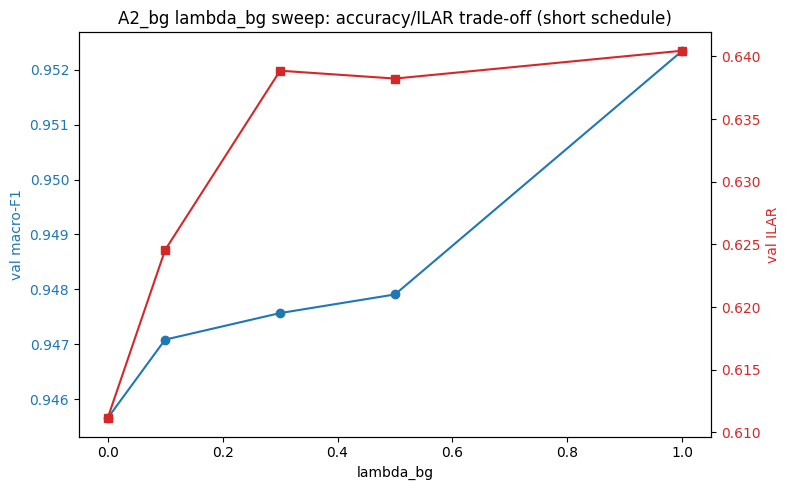

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
plot_df = bg_tuning_df.sort_values("lambda_bg")

ax1.plot(plot_df["lambda_bg"], plot_df["val_macro_f1_at_best"], "o-", color="tab:blue", label="val macro-F1")
ax2.plot(plot_df["lambda_bg"], plot_df["val_ilar_at_best"], "s-", color="tab:red", label="val ILAR")
ax1.set_xlabel("lambda_bg")
ax1.set_ylabel("val macro-F1", color="tab:blue")
ax2.set_ylabel("val ILAR", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("A2_bg lambda_bg sweep: accuracy/ILAR trade-off (short schedule)")
fig.tight_layout()

BG_FIG_DIR = REPO_ROOT / "artifacts" / "T18_lung_attention" / "bg_suppression_followup" / "figures"
BG_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(BG_FIG_DIR / "bg_lambda_sweep.png", dpi=150)
plt.show()


## Step 3 -- selection rule for lambda_bg*

Same pre-registered rule as T18's own S9 (module card section 3 / WBS section 5.3): the largest
value within tolerance of the reference row's val macro-F1, ties broken by higher val ILAR. Here
the reference is `bg_0.0` (plain A2), not `lam_0.0` -- this sweep is entirely about the new axis,
`lambda_att` is already fixed at `LAMBDA_STAR` for every row.

In [12]:
TOLERANCE = 0.005  # 0.5 percentage points, absolute -- same tolerance T18 used for lambda_att

reference_row = bg_tuning_df[bg_tuning_df["name"] == "bg_0.0"].iloc[0]
reference_f1 = reference_row["val_macro_f1_at_best"]
print(f"Reference (bg_0.0 == plain A2) val macro-F1: {reference_f1:.4f}")

candidates = bg_tuning_df[bg_tuning_df["val_macro_f1_at_best"] >= reference_f1 - TOLERANCE].copy()
if candidates.empty:
    raise RuntimeError(
        "No lambda_bg satisfies the 0.5pp tolerance -- extend the grid downward "
        "(e.g. {0.05, 0.03}) rather than relaxing the tolerance, per T18's own precedent."
    )

max_lambda_bg = candidates["lambda_bg"].max()
tied = candidates[candidates["lambda_bg"] == max_lambda_bg].sort_values("val_ilar_at_best", ascending=False)
winner_row = tied.iloc[0]

LAMBDA_BG_STAR = float(winner_row["lambda_bg"])
selected_bg = {
    "lambda_bg": LAMBDA_BG_STAR,
    "lambda_att": LAMBDA_STAR,
    "rule": "largest lambda_bg whose val macro-F1 is within 0.5pp of bg_0.0 (plain A2); ties -> higher val ILAR",
    "reference_row": "bg_0.0",
    "reference_val_macro_f1": float(reference_f1),
    "schedule": f"short({TUNE_PHASE1_EPOCHS}+{TUNE_PHASE2_EPOCHS})",
    "seed": SEED,
}
with open(BG_SWEEP_ROOT / "selected_bg_config.json", "w") as f:
    json.dump(selected_bg, f, indent=2)

print(f"Selected lambda_bg* = {LAMBDA_BG_STAR}")
print(json.dumps(selected_bg, indent=2))


Reference (bg_0.0 == plain A2) val macro-F1: 0.9457
Selected lambda_bg* = 1.0
{
  "lambda_bg": 1.0,
  "lambda_att": 1.0,
  "rule": "largest lambda_bg whose val macro-F1 is within 0.5pp of bg_0.0 (plain A2); ties -> higher val ILAR",
  "reference_row": "bg_0.0",
  "reference_val_macro_f1": 0.945651943281733,
  "schedule": "short(4+6)",
  "seed": 42
}


## Step 4 -- train A2_bg at full schedule

Same two-phase schedule as every other T18 arm (`run_full_arm`, unchanged), just with `lambda_bg`
set in the arm's own config via `merge_overrides` -- exactly how every other arm's flags differ
from the base config. `configs/densenet121_lung_attention.yaml` itself is never edited.

**Run this on Kaggle (GPU), not locally.** Same order of magnitude as A2's own full run (~2.5-4h
on a T4).

In [13]:
A2BG_RUNS_ROOT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "bg_suppression_followup" / "runs"

a2_bg_cfg = merge_overrides(cfg, {
    "module.use_attention": True, "module.attention": "lung",
    "module.gate_mode": "residual", "module.lambda_att": LAMBDA_STAR,
    "module.lambda_bg": LAMBDA_BG_STAR,
    "experiment.name": "T18-A2-bg",
})

A2_BG_OUT = A2BG_RUNS_ROOT / "A2_bg"
a2_bg_results = run_full_arm(
    "A2_bg", a2_bg_cfg, train_loader, val_loader, test_loader, class_names, criterion,
    device, A2_BG_OUT, backbone_name="densenet121", wandb_enabled=True,
)
print(f"\nSaved checkpoint to {A2_BG_OUT / 'densenet121_A2_bg.pt'}")


wandb: Tracking run with wandb version 0.26.1
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /kaggle/working/wandb/offline-run-20260923_105537-itmx0l66


[phase1_frozen] epoch 1/15 train_loss=1.0810 (cls=0.6448, att=0.3569) train_acc=0.7087 | val_loss=0.8839 (cls=0.4921, att=0.3207) val_acc=0.8107 val_f1=0.8037 val_ilar=0.5991


[phase1_frozen] epoch 2/15 train_loss=0.9697 (cls=0.5775, att=0.3208) train_acc=0.7472 | val_loss=0.7943 (cls=0.4163, att=0.2964) val_acc=0.8488 val_f1=0.8510 val_ilar=0.5983


[phase1_frozen] epoch 3/15 train_loss=0.9686 (cls=0.5854, att=0.3116) train_acc=0.7477 | val_loss=0.8510 (cls=0.4771, att=0.3038) val_acc=0.8167 val_f1=0.8213 val_ilar=0.6225


[phase1_frozen] epoch 4/15 train_loss=0.9756 (cls=0.5976, att=0.3069) train_acc=0.7498 | val_loss=0.8427 (cls=0.4781, att=0.2890) val_acc=0.8161 val_f1=0.8136 val_ilar=0.6303


...

[phase2_finetune] epoch 13/40 train_loss=0.3814 (cls=0.0722, att=0.2424) train_acc=0.9641 | val_loss=0.4604 (cls=0.1572, att=0.2364) val_acc=0.9506 val_f1=0.9556 val_ilar=0.6753


[phase2_finetune] epoch 14/40 train_loss=0.3729 (cls=0.0642, att=0.2418) train_acc=0.9687 | val_loss=0.4610 (cls=0.1581, att=0.2362) val_acc=0.9515 val_f1=0.9582 val_ilar=0.6757


[phase2_finetune] epoch 15/40 train_loss=0.3626 (cls=0.0544, att=0.2414) train_acc=0.9724 | val_loss=0.4550 (cls=0.1523, att=0.2361) val_acc=0.9553 val_f1=0.9620 val_ilar=0.6761
[phase2_finetune] Early stopping at epoch 15 (no improvement for 5 epochs).


wandb: 
wandb: Run history:
wandb:          epoch ▁▁▂▃▃▃▄▅▅▅▆▇▇▇█▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
wandb:  learning_rate █████████▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: train_att_loss █▆▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb:  train_bg_loss █▄▄▃▄▃▃▃▂▃▃▃▃▃▄▃▃▂▂▂▂▁▁▂▁▁▁▁▁▁
wandb: train_cls_loss █▇▇▇▇▇▇▇█▇▇▆▆▆▆▅▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:     train_loss █▇▇▇▇▇▇▇▇▇▆▆▆▆▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:   val_accuracy ▁▃▁▁▂▂▃▃▂▃▃▃▃▃▃▆▆▆▇▇▇▇█▇██████
wandb:   val_att_loss █▆▇▅▄▅▄▄▄▅▄▄▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:    val_bg_loss ▃█▃▅█▁▅▅█▃▄▅▄▅▅▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
wandb:   val_cls_loss █▆██▇▇▆▆▇▇▆▆▆▆▆▃▂▂▂▂▁▂▁▁▁▁▁▁▁▁
wandb:             +5 ...
wandb: 
wandb: Run summary:
wandb:                         epoch 15
wandb:                 learning_rate 1e-05
wandb:      phase1_frozen_best_epoch 14
wandb:     phase1_frozen_best_val_f1 0.8599
wandb:   phase1_frozen_best_val_loss 0.73038
wandb:    phase2_finetune_best_epoch 10
wandb:   phase2_finetune_best_val_f1 0.95736
wandb: phase2_finetune_best_val_loss 0.45305
wandb:                train_att_loss 0.24139
w


=== Test set performance ===
Test accuracy: 0.9493
                 precision    recall  f1-score   support

          COVID     0.9794    0.9649    0.9721       542
   Lung_Opacity     0.9554    0.9024    0.9282       902
         Normal     0.9322    0.9712    0.9513      1529
Viral Pneumonia     0.9796    0.9505    0.9648       202

       accuracy                         0.9493      3175
      macro avg     0.9616    0.9473    0.9541      3175
   weighted avg     0.9499    0.9493    0.9491      3175

Confusion matrix:
 [[ 523    5   13    1]
 [   2  814   86    0]
 [   8   33 1485    3]
 [   1    0    9  192]]
Macro ROC-AUC: 0.9934
Attention ILAR: 0.6715 | Dice: 0.7592 | IoU: 0.6225

Saved checkpoint to /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/bg_suppression_followup/runs/A2_bg/densenet121_A2_bg.pt


## Step 5 -- load A0 and A2 for comparison

**Requires T18's own A0/A2 checkpoints to be available in this session.** Per
`T18_module_card.md`, `.pt` files are gitignored and not committed to the repo -- attach them as
a Kaggle Dataset (Kaggle: *Add Data -> your own T18 notebook's Output*, or a dataset you uploaded
the checkpoints to) and point `A0_CKPT_PATH` / `A2_CKPT_PATH` below at wherever that lands. This
cell fails loudly rather than silently comparing against nothing if they're missing.

In [14]:
def load_arm_model(ckpt_path, backbone_name="densenet121"):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    arm_cfg = ckpt["config"]
    m = arm_cfg["module"]
    model = build_model(
        num_classes=arm_cfg["model"]["num_classes"],
        use_attention=m["use_attention"], attention=m.get("attention", "lung"),
        gate_mode=m.get("gate_mode", "residual"), reduction=m.get("reduction", 8),
        backbone_name=backbone_name, pretrained=False,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, arm_cfg, ckpt.get("class_names", class_names)


# Adjust these two paths to wherever T18's A0/A2 checkpoints actually landed in this session.
A0_CKPT_PATH = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs" / "A0_vanilla" / "densenet121_A0_vanilla.pt"
A2_CKPT_PATH = REPO_ROOT / "artifacts" / "T18_lung_attention" / "runs" / "A2_full" / "densenet121_A2_full.pt"

ARM_CHECKPOINTS = {
    "A0_vanilla": A0_CKPT_PATH,
    "A2_full": A2_CKPT_PATH,
    "A2_bg": A2_BG_OUT / "densenet121_A2_bg.pt",
}
for name, p in ARM_CHECKPOINTS.items():
    print(f"{name}: {'OK' if p.exists() else 'MISSING'} -- {p}")

missing = [n for n, p in ARM_CHECKPOINTS.items() if not p.exists()]
if missing:
    print(f"\nMissing checkpoints: {missing}. Attach T18's A0/A2 outputs as a Kaggle Dataset "
          "(Add Data -> your T18 notebook's Output) and re-point A0_CKPT_PATH/A2_CKPT_PATH above "
          "before running the comparison cells below.")


A0_vanilla: MISSING -- /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/runs/A0_vanilla/densenet121_A0_vanilla.pt
A2_full: MISSING -- /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/runs/A2_full/densenet121_A2_full.pt
A2_bg: OK -- /kaggle/working/Chest-X-ray-Disease-Detection/artifacts/T18_lung_attention/bg_suppression_followup/runs/A2_bg/densenet121_A2_bg.pt

Missing checkpoints: ['A0_vanilla', 'A2_full']. Attach T18's A0/A2 outputs as a Kaggle Dataset (Add Data -> your T18 notebook's Output) and re-point A0_CKPT_PATH/A2_CKPT_PATH above before running the comparison cells below.


## Step 6 -- comparison table (A0 vs. A2 vs. A2_bg)

Same schema as `T18_comparison_table.csv`, written to a **separate** file so it never overwrites
T18's own committed results.

In [15]:
cam_subset = stratified_cam_subset(datasets["test"], n=1000, seed=cfg["experiment"]["seed"])
print(f"Fixed CAM subset: {len(cam_subset)} images (same convention as T18's own S11)")

BG_OUT = REPO_ROOT / "artifacts" / "T18_lung_attention" / "bg_suppression_followup"
BG_OUT.mkdir(parents=True, exist_ok=True)

arms_for_table = {}
for arm_name, ckpt_path in ARM_CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f"SKIPPING {arm_name}: checkpoint not found")
        continue
    print(f"\n=== {arm_name} ===")
    model, arm_cfg, arm_class_names = load_arm_model(ckpt_path)
    arm_dir = ckpt_path.parent
    results_path = arm_dir / "phase2_finetune_test_results.json"
    assert results_path.exists(), f"{results_path} missing"
    with open(results_path) as f:
        evaluate_results = json.load(f)

    per_image_df = build_per_image_predictions(model, datasets["test"], arm_class_names, device, cam_subset=cam_subset)
    per_image_df.to_csv(arm_dir / "per_image_predictions.csv", index=False)

    arms_for_table[arm_name] = {
        "gate_mode": arm_cfg["module"].get("gate_mode") if arm_cfg["module"]["use_attention"] else "none",
        "lambda_att": arm_cfg["module"]["lambda_att"],
        "evaluate_results": evaluate_results,
        "per_image_df": per_image_df,
    }

comparison_df = build_comparison_table(
    arms_for_table, reference_arm="A0_vanilla" if "A0_vanilla" in arms_for_table else None,
    output_csv=BG_OUT / "T18_A2bg_comparison_table.csv",
)
comparison_df


Fixed CAM subset: 1000 images (same convention as T18's own S11)
SKIPPING A0_vanilla: checkpoint not found
SKIPPING A2_full: checkpoint not found

=== A2_bg ===


,arm,gate,lambda,test_acc,test_macro_f1,test_auc_macro,ILAR,att_dice,EIL_post,EIL_pre,delta_macro_f1,delta_eil_post,delta_eil_pre
0,A2_bg,residual,1.0,0.949291,0.954105,0.993364,0.671546,0.759214,0.358605,0.296531,0.0,0.0,0.0


In [16]:
if "A2_bg" in arms_for_table:
    verdicts = check_acceptance_criteria(comparison_df, headline_arm="A2_bg")
    for name, v in verdicts.items():
        status = "PASS" if v["pass"] else "FAIL"
        print(f"[{status}] {name}: {v['value']:.4f} (target: {v['target']})")
    with open(BG_OUT / "acceptance_criteria_A2bg.json", "w") as f:
        json.dump(verdicts, f, indent=2)
else:
    print("A2_bg not in arms_for_table -- run Step 4/5 first.")


[FAIL] A1_attention_matches_lung_mask: 0.7592 (target: Attention-Dice >= 0.80 on test)
[FAIL] A2_evidence_inside_lung_up: 0.0000 (target: delta Grad-CAM EIL (post-gate) >= +0.05)
[FAIL] A3_mechanism_is_real: 0.0000 (target: delta Grad-CAM EIL (pre-gate) > 0)
[PASS] A4_no_accuracy_tax: 0.0000 (target: delta test macro-F1 >= -1.0pp vs. A0)


## Step 7 -- the actual question: did background attention go down?

This is the metric that directly targets the observation that motivated this notebook: even in
A2, some attention mass still sits on non-lung regions (e.g. the acquisition marker). `EIL`
(Step 6's table) measures Grad-CAM *evidence*; `background_attention` measures the *attention
module's own map*, independent of ILAR (which is dominated by the much larger lung region) --
computed once here, directly, on the full test set, using the unmodified
`src/modules/attention_metrics.py::background_attention` function.

In [17]:
from torch.utils.data import DataLoader

def mean_background_attention(model, dataset, device, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    vals = []
    model.eval()
    with torch.no_grad():
        for images, _labels, masks in loader:
            images, masks = images.to(device), masks.to(device).float()
            if masks.ndim == 3:
                masks = masks.unsqueeze(1)
            _, att, _ = model(images)
            if att is None:
                continue
            vals.append(background_attention(att.float(), masks).cpu())
    return torch.cat(vals).mean().item() if vals else float("nan")


bg_attention_summary = {}
for arm_name in ["A2_full", "A2_bg"]:
    if arm_name not in arms_for_table or not ARM_CHECKPOINTS[arm_name].exists():
        continue
    model, _arm_cfg, _ = load_arm_model(ARM_CHECKPOINTS[arm_name])
    bg_attention_summary[arm_name] = mean_background_attention(model, datasets["test"], device)
    print(f"{arm_name}: mean background_attention = {bg_attention_summary[arm_name]:.4f}")

if "A2_full" in bg_attention_summary and "A2_bg" in bg_attention_summary:
    delta = bg_attention_summary["A2_bg"] - bg_attention_summary["A2_full"]
    print(f"\nDelta (A2_bg - A2_full): {delta:+.4f} "
          f"({'lower' if delta < 0 else 'higher'} background attention with the suppression loss)")

with open(BG_OUT / "background_attention_summary.json", "w") as f:
    json.dump(bg_attention_summary, f, indent=2)


A2_bg: mean background_attention = 0.0865


## Handoff notes

- All outputs of this notebook live under `artifacts/T18_lung_attention/bg_suppression_followup/`
  -- a separate folder from T18's own `runs/`/`sweep/`/`figures/`, so nothing here can be confused
  with or overwrite the frozen A0-A5 results already in the paper.
- `lambda_bg*` (Step 3) was selected by the same pre-registered short-schedule rule T18 used for
  `lambda_att`, but this is the **first time this axis has been tuned at all** -- treat the result
  as a first data point, not a validated final value the way `lambda_att=1.0` now is.
- A lower `background_attention` and/or higher `EIL` for A2_bg vs. A2 is evidence the extra loss
  term is doing something -- it is **not**, on its own, evidence of reduced shortcut *dependence*.
  That still needs the counterfactual/region-perturbation test (`src/modules/counterfactual.py`,
  implemented, not yet run against real checkpoints -- module card section 10) to actually measure
  whether predictions become less sensitive to background perturbation.
- Worth re-generating the qualitative 3-panel figure (`covid_shortcut_example_crop.png`'s own
  source image) for A2_bg specifically, to see by eye whether the residual marker-region heat from
  A2's third panel is actually reduced -- `src/modules/figures.py`'s heatmap-overlay helpers,
  reused unchanged, would produce this.
